In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [3]:
df = pd.read_csv("mobile_price_data.csv")
df.head()


,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


In [3]:
df.tail()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
536,637,SAMSUNG Galaxy S23 5G,Cream,256,8,3900,50MP,12MP,0,15.49,Qualcomm Snapdragon 8 Gen 2,"79,999"
537,638,LAVA Z21,Cyan,32,2,3100,5MP,2MP,0,12.70,Octa Core,"5,998"
538,639,Tecno Spark 8T,Turquoise Cyan,64,4,5000,50MP,8MP,0,16.76,MediaTek Helio G35,"9,990"
539,641,SAMSUNG Galaxy A54 5G,Awesome Lime,128,8,5000,50MP,32MP,0,16.26,"Exynos 1380, Octa Core","38,999"
540,642,OPPO A77,Sky Blue,128,4,5000,50MP,8MP,0,16.66,Mediatek Helio G35,"15,999"


In [4]:
df.shape




(541, 12)

In [5]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 50.8+ KB


In [8]:
df.describe()


,Unnamed: 0,Memory,RAM,Battery_,AI Lens,Mobile Height
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,289.711645,110.550832,5.397412,4871.587800,0.062847,16.431201
std,182.359185,60.600694,1.984923,780.148862,0.242911,2.523553
min,0.000000,16.000000,2.000000,800.000000,0.000000,4.500000
25%,135.000000,64.000000,4.000000,5000.000000,0.000000,16.510000
50%,273.000000,128.000000,6.000000,5000.000000,0.000000,16.710000
75%,434.000000,128.000000,8.000000,5000.000000,0.000000,16.940000
max,642.000000,256.000000,8.000000,7000.000000,1.000000,41.940000


In [15]:
df.columns


Index(['Model', 'Memory', 'RAM', 'Battery_', 'Rear Camera', 'Front Camera',
       'AI Lens', 'Mobile Height', 'Processor_', 'Prize', 'Camera_Category'],
      dtype='object')

Handling Missing Values

In [10]:
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

# Data Cleaning

 Remove Unnecessary Columns

In [14]:
df = df.drop(columns=['Unnamed: 0', 'Colour'], errors='ignore')

check Duplicates Values 

In [5]:
df.duplicated().sum()

np.int64(0)

Insights:

The result returned 0, which means there are no duplicate rows present in the dataset. Therefore, no duplicate removal was required.

Rename Price column 

In [7]:
df.rename(columns={"Prize": "Price"}, inplace=True)

Clean Price Column


In [9]:

df['Price'] = df['Price'].astype(str).str.replace(',', '', regex=False)
df['Price'] = df['Price'].astype(int)


In [8]:
X = df.drop(['Price','Model'], axis=1)

Clean Camera Columns

In [11]:
df['Rear Camera'] = df['Rear Camera'].astype(str).str.replace('MP', '', regex=False).astype(int)
df['Front Camera'] = df['Front Camera'].astype(str).str.replace('MP', '', regex=False).astype(int)


Data Preprocessing

In [31]:
df = pd.get_dummies(df, drop_first=True)

Data preprocessing ensures clean, consistent, and machine-readable input.
Categorical variables must be converted into numerical format for ML models.

IQR Method , Outliers :-

In [7]:
# select only numeric columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

# calculate Q1 and Q3
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

# calculate IQR
IQR = Q3 - Q1

# remove outliers
df = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) | 
          (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

 Encode Categorical Columns

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Processor_'] = le.fit_transform(df['Processor_'])



Feature Extraction - Correlation

In [20]:
numeric_df = df.select_dtypes(include=['int64','float64'])

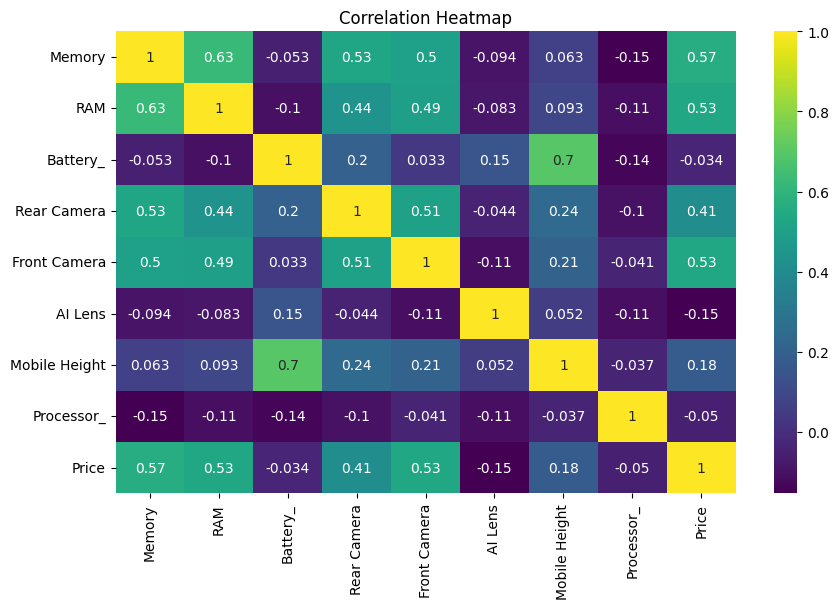

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='viridis')
plt.title("Correlation Heatmap")
plt.show()

Insights:-

RAM and Price show strong positive correlation

Battery and camera also influence mobile price

The heatmap shows the relationship between different mobile features and price.

RAM has a strong positive correlation with price, indicating that phones with higher RAM tend to be more expensive.

Memory (storage) also shows a positive relationship with price, meaning higher storage phones usually cost more.

Rear camera quality has a moderate correlation with price, suggesting better cameras are often found in higher-priced phones.

Battery capacity shows a slight positive relationship with price, but its impact is lower compared to RAM and memory.

Overall, RAM, memory, and camera specifications are the most important factors influencing mobile price.


Feature Importance (Random Forest)

In [33]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop('Price', axis=1)
y = df['Price']

model = RandomForestRegressor()
model.fit(X, y)

importances = model.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

Front Camera                  0.490191
Battery_                      0.092249
Model_APPLE iPhone 14 Plus    0.080636
Memory                        0.069255
Model_Google Pixel 7          0.047346
Brand_Google                  0.034051
Rear Camera                   0.031623
Processor_                    0.029311
RAM                           0.027618
Mobile Height                 0.025594
dtype: float64

In [22]:
df["Price"].describe()


count      541.000000
mean     16228.375231
std      10793.588322
min        920.000000
25%       9290.000000
50%      13499.000000
75%      19280.000000
max      80999.000000
Name: Price, dtype: float64

Clean Price Column

In [24]:
df['Price'] = df['Price'].astype(str).str.replace(',', '', regex=False)
df['Price'] = df['Price'].astype(int)


In [33]:
y = df['Price']

Clean Camera Columns

In [ ]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")

 Check Final Data Types

In [25]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          541 non-null    object 
 1   Memory         541 non-null    int64  
 2   RAM            541 non-null    int64  
 3   Battery_       541 non-null    int64  
 4   Rear Camera    541 non-null    int64  
 5   Front Camera   541 non-null    int64  
 6   AI Lens        541 non-null    int64  
 7   Mobile Height  541 non-null    float64
 8   Processor_     541 non-null    int64  
 9   Price          541 non-null    int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 42.4+ KB
None


#UNIVARIANT ANALYSIS -

# Mobile Price Distribution:-

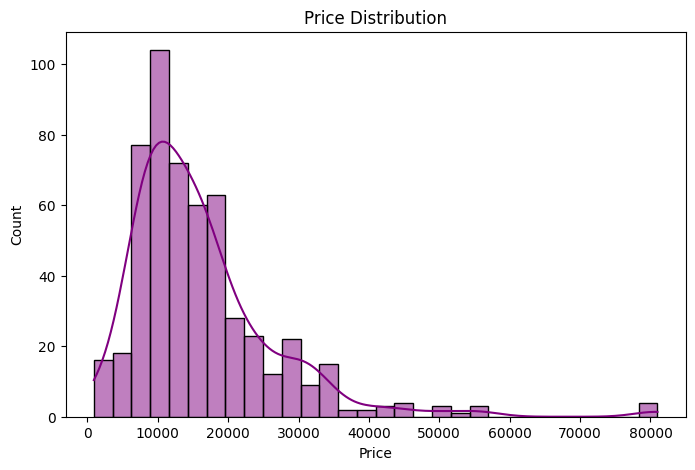

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Price'], 
             bins=30, 
             kde=True,
             color='purple')

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

Insight:

-Most mobiles are in low to mid price range.

-Very few mobiles are highly expensive.

-Data is slightly right-skewed (more affordable phones).

Univariate Analysis – RAM

Check Unique Values:-
This tells us what RAM sizes are available (like 4GB, 6GB, 8GB).

In [ ]:
df['RAM'].unique()


array([4, 8, 2, 6, 3])

# Bar Chart for RAM:-

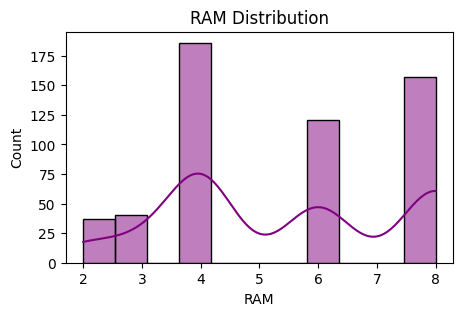

In [ ]:
plt.figure(figsize=(5,3))
sns.histplot(df['RAM'], kde=True, color='#800080')
plt.title("RAM Distribution")
plt.show()



Insights – RAM Distribution:
The dataset shows that the majority of smartphones fall under the 4GB and 6GB RAM category, indicating strong demand in the mid-range segment.

-Most mobiles have 4GB and 6GB RAM 

-8GB RAM models are moderate in number

-Very few mobiles have 12GB RAM

-Market mainly focuses on mid-range RAM segment

# Battery

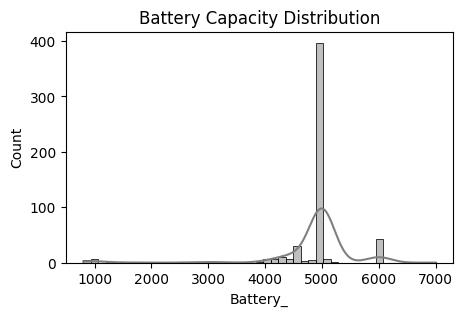

In [ ]:
plt.figure(figsize=(5,3))
sns.histplot(df['Battery_'], kde=True, color='#808080')
plt.title("Battery Capacity Distribution")
plt.show()


Insights-

Most mobiles fall in 4000–6000 mAh range

Very few mobiles have battery below 3000 mAh

High battery capacity phones dominate the market

# Memory

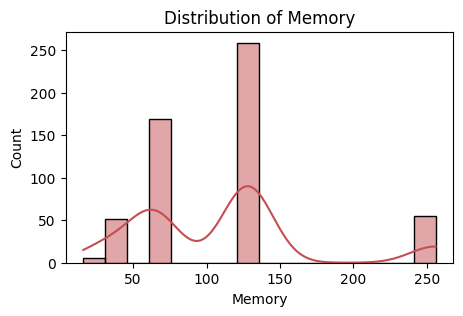

In [ ]:
plt.figure(figsize=(5,3))
sns.histplot(df['Memory'],kde=True, color='#C44E52')
plt.title('Distribution of Memory')
plt.show()

Insights-

-Most mobiles have 64GB and 128GB storage

-256GB models are moderate in number

-Very few mobiles offer 512GB storage

-Market mainly focuses on mid-storage segment (64–128GB)

# Mobile Height:-


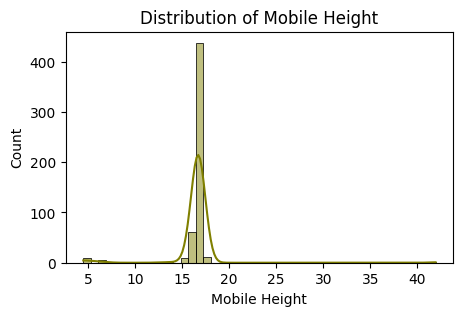

In [ ]:
plt.figure(figsize=(5,3))
sns.histplot(df['Mobile Height'], kde=True, color='#808000')
plt.title('Distribution of Mobile Height')
plt.show()

Insights:-

-Most mobiles have medium height range

-Very small and very large height mobiles are fewer

-Height variation is not very large

-Most smartphones follow standard screen size design

-The distribution shows that most smartphones have similar height dimensions, indicating standardization in screen design.

# Rear Camera:-

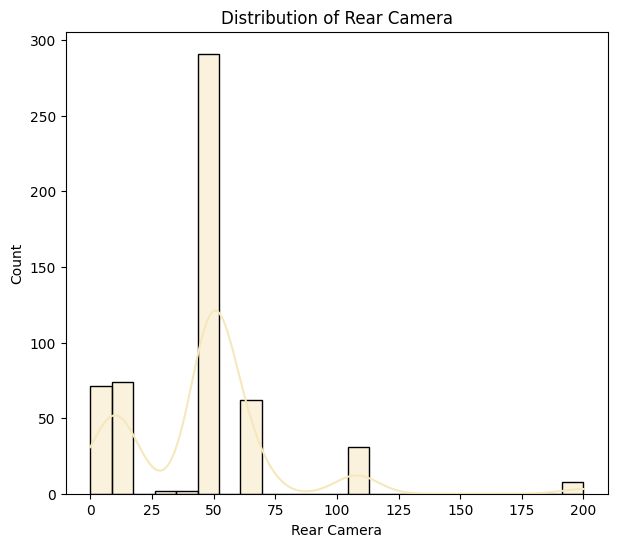

In [ ]:
plt.figure(figsize=(7,6))
sns.histplot(df['Rear Camera'], kde=True, color='#F6E7BC')
plt.title('Distribution of Rear Camera')
plt.show()

Insights:-

-Majority of mobiles have 48MP or 64MP rear camera

-Very high MP cameras (108MP+) are fewer

-Low MP cameras are less common

-Market focuses on mid to high camera quality

-The dataset indicates that most smartphones are equipped with 48MP or 64MP rear cameras, reflecting the growing importance of camera performance in purchasing decisions.

# Front Camera :-

In [ ]:
df['Front Camera'].dtype

dtype('int64')

In [ ]:
df['Front Camera'] = df['Front Camera'].astype(str)

In [ ]:
df['Front Camera'] = df['Front Camera'].str.replace('MP', '', regex=False).str.strip()
df['Front Camera'] = pd.to_numeric(df['Front Camera'], errors='coerce')

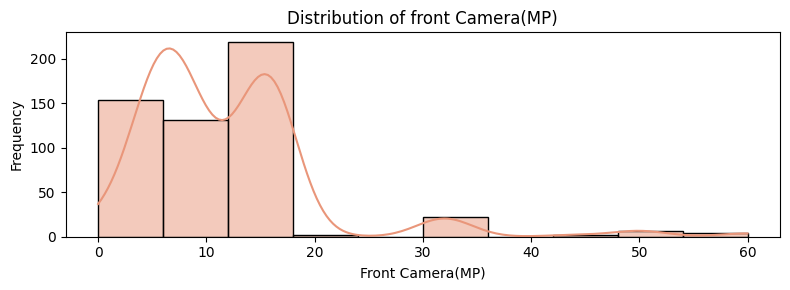

In [ ]:
plt.figure(figsize=(8,3))
sns.histplot(df['Front Camera'], bins=10, kde=True, color='#E9967A')
plt.title('Distribution of front Camera(MP)')
plt.xlabel('Front Camera(MP)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


# Mobiles Models Distribution

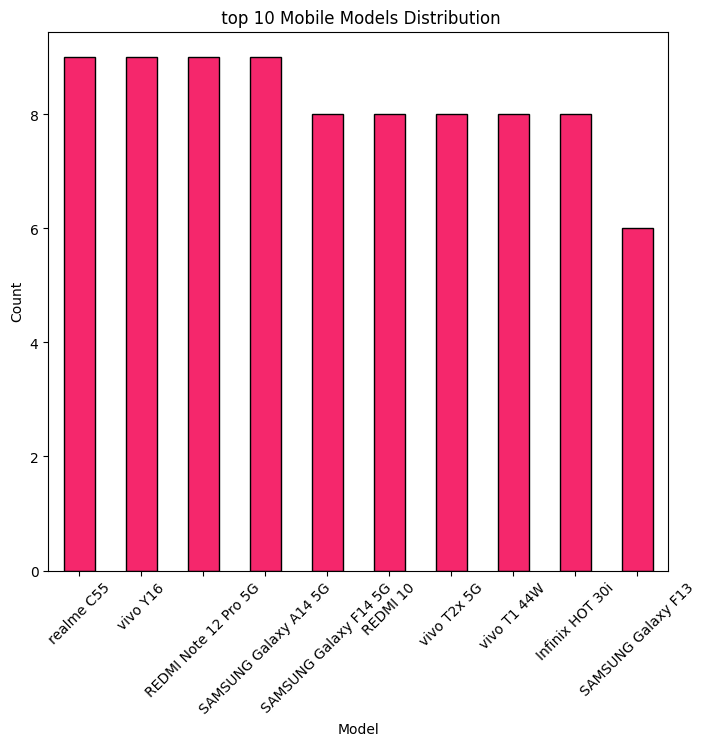

In [ ]:
plt.figure(figsize=(8,7))

df['Model'].value_counts().head(10).plot(
    kind='bar',
    color='#F5276C',
    edgecolor='black'
)

plt.title(" top 10 Mobile Models Distribution")
plt.xlabel("Model")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()


Insights:-
-Some models appear more frequently than others

-Only a few models dominate the dataset

-Many models appear only once or twice

-Dataset contains a wide variety of models


# Brand Distribution :-

In [ ]:
df['Brand'] = df['Model'].str.split().str[0]


This extracts first word as brand name.

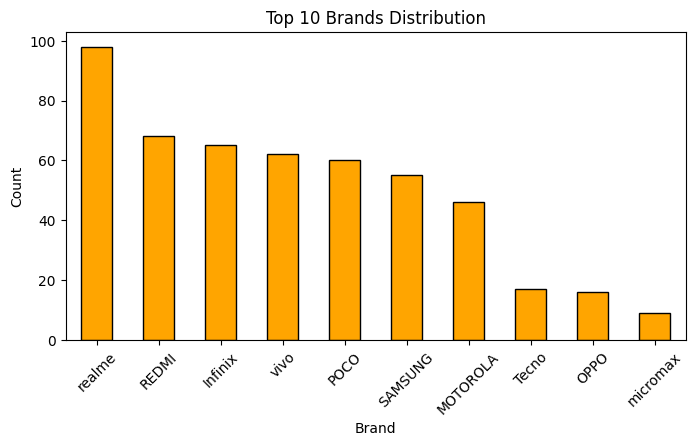

In [ ]:
plt.figure(figsize=(8,4))

df['Brand'].value_counts().head(10).plot(
    kind='bar',
    color='orange',
    edgecolor='black'
)

plt.title("Top 10 Brands Distribution")
plt.xlabel("Brand")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()


insights:-

-Few brands dominate the dataset

-Some brands have very few models

-Market is competitive but concentrated

-The dataset shows that a few major brands dominate the smartphone market, while several smaller brands have limited representation.

# Top Processor distribution :-

In [ ]:
df['Processor_'].value_counts()

Processor_
Qualcomm Snapdragon 680                     33
Unisoc T612                                 21
Mediatek Helio A22                          19
Mediatek Dimensity 1080                     18
Qualcomm Snapdragon 695 5G                  17
                                            ..
6 Core                                       1
Dimensity 8200                               1
Qualcomm SM6225 Snapdragon 680 4G (6 nm)     1
Exynos Octa Core                             1
Qualcomm Snapdragon 8 Gen 2                  1
Name: count, Length: 123, dtype: int64

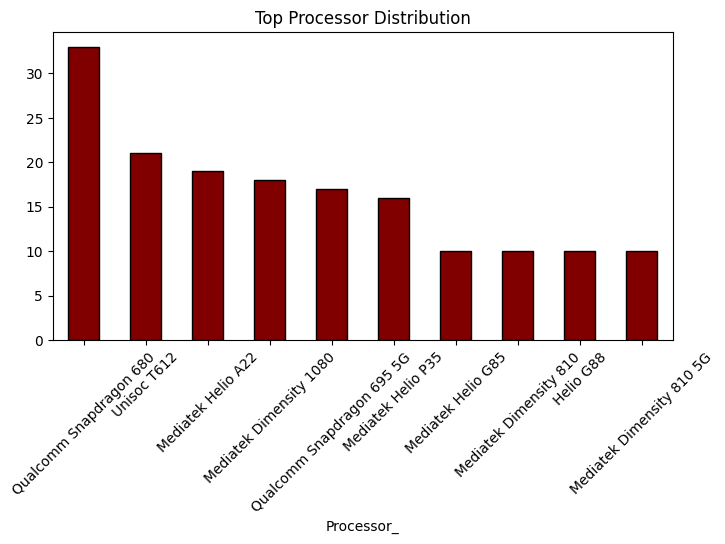

In [ ]:
plt.figure(figsize=(8,4))

df['Processor_'].value_counts().head(10).plot(
    kind='bar',
    color='#800000',
    edgecolor='black'
)

plt.title("Top Processor Distribution")
plt.xticks(rotation=45)
plt.show()

Insights:-

Most phones use budget processors like:

Unisoc Spreadtrum SC9863A1

MediaTek Helio series

G37 / Helio G36

Only a few models use Qualcomm Snapdragon 680.

This suggests the dataset mainly contains budget and mid-range smartphones.

# Distribution Of AI Lens

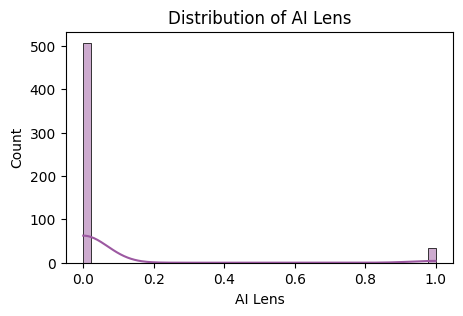

In [ ]:
plt.figure(figsize=(5,3))
sns.histplot(df['AI Lens'], kde=True, color='#9C58A1')
plt.title('Distribution of AI Lens')
plt.show()

Insights :-
1.Majority Trend
-Most phones have value 1
-Fewer phones have value 0
-This means most smartphones in the dataset include AI lens features.

2.Feature Standardization
-AI lens is becoming a common feature, even in budget smartphones.
-It is no longer a premium-only feature.

3.Market Strategy Insight
Brands are adding AI lens to:
-Improve camera marketing
-Enhance image processing
-Attract budget customers

4.Overall Observation
-The distribution shows that AI-based camera enhancements are widely adopted, 
especially in the ₹5,000–₹10,000 range.

# Bivariant Analysis

RAM vs Price

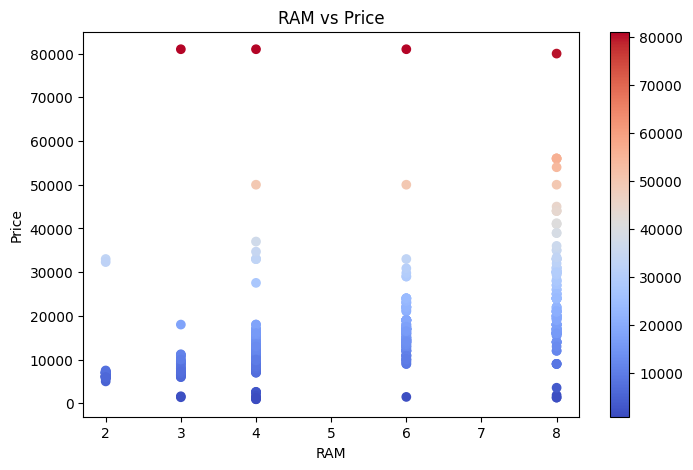

In [ ]:
plt.figure(figsize=(8,5))

scatter = plt.scatter(df['RAM'], df['Price'], 
                      c=df['Price'], 
                      cmap='coolwarm')

plt.colorbar(scatter)
plt.title("RAM vs Price")
plt.xlabel("RAM")
plt.ylabel("Price")
plt.show()


Insight:

-Strong positive relationship.

-As RAM increases, price increases.

-RAM is one of the most important pricing factors.

Battery vs Price

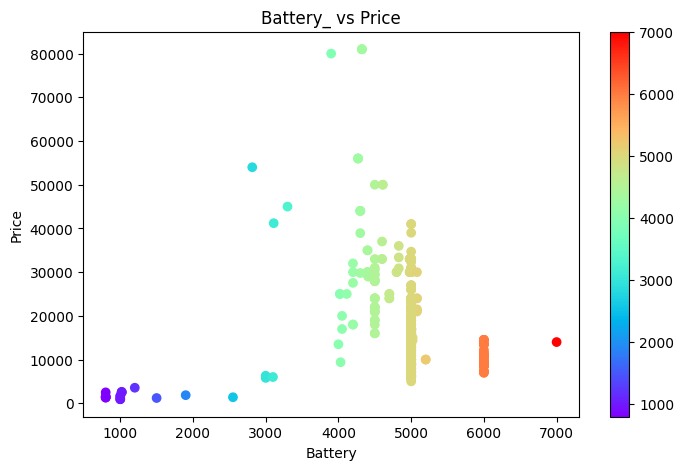

In [ ]:
plt.figure(figsize=(8,5))

scatter = plt.scatter(df['Battery_'], df['Price'], 
                      c=df['Battery_'], 
                      cmap='rainbow')

plt.colorbar(scatter)
plt.title("Battery_ vs Price")
plt.xlabel("Battery")
plt.ylabel("Price")
plt.show()

Insight:

Slight positive trend.

Bigger battery slightly increases price.

But battery alone does not decide price

Brand vs Avg Price

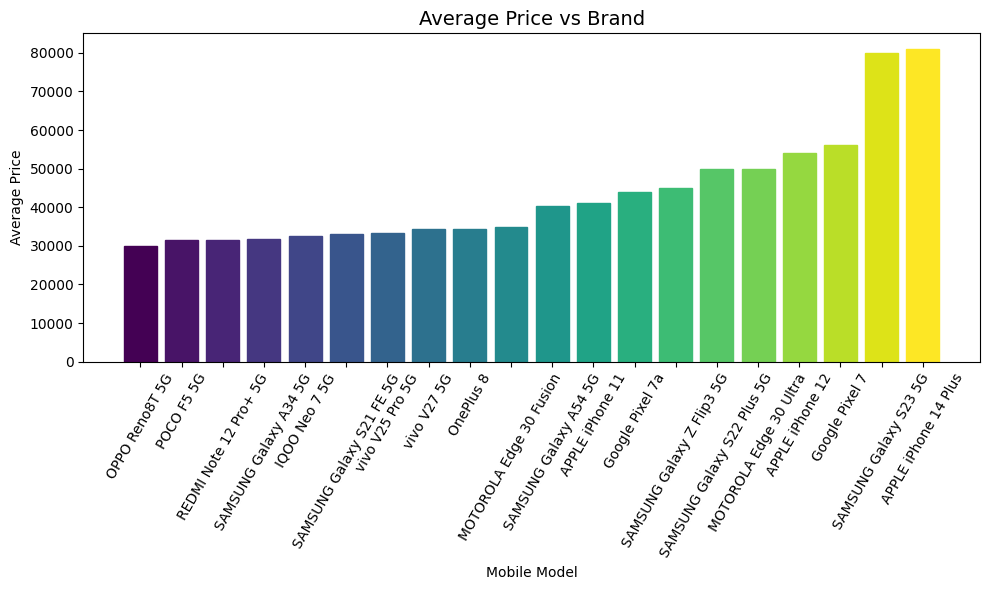

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Group by Model and calculate average price
brand_price = df.groupby('Model')['Price'].mean().sort_values()

# Take only top 20 to make graph clean
brand_price = brand_price.tail(20)

plt.figure(figsize=(10,6))

bars = plt.bar(brand_price.index, brand_price.values)

# Apply gradient colors (same style as your graph)
colors = plt.cm.viridis(np.linspace(0,1,len(bars)))

for color, bar in zip(colors, bars):
    bar.set_color(color)

plt.title("Average Price vs Brand", fontsize=14)
plt.xlabel("Mobile Model")
plt.ylabel("Average Price")

plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

Insight:

-Premium brands have higher average prices.

-Budget brands offer lower-priced mobiles.

-The graph shows the average price distribution of different mobile models.

- Some models fall in the premium price range, while others belong to budget segments.

- There is a significant variation in price across different models.

-This indicates that mobile specifications strongly influence pricing.

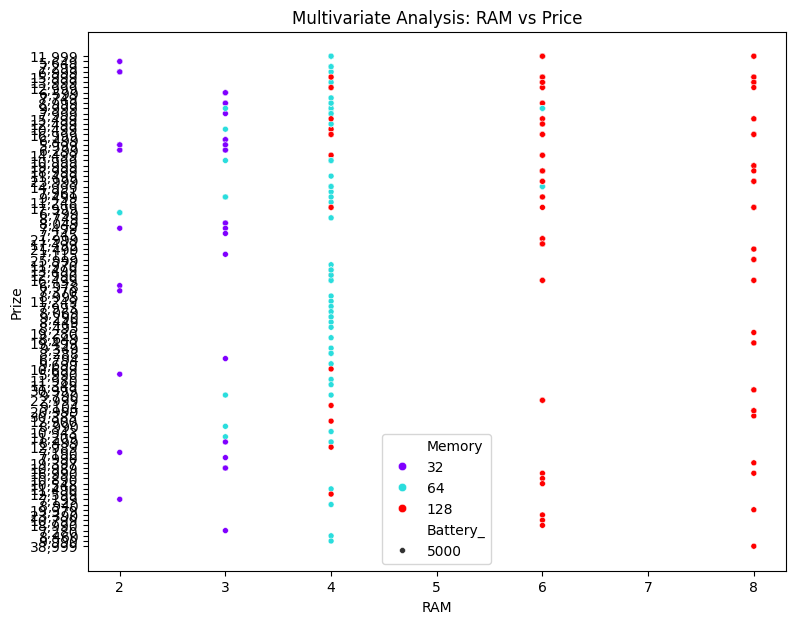

In [18]:
plt.figure(figsize=(9,7))

sns.scatterplot(
    data=df,
    x='RAM',
    y='Prize',
    hue='Memory',
    size='Battery_',
    palette='rainbow'
)

plt.title("Multivariate Analysis: RAM vs Price")
plt.show()

# Feature Extraction

A. Extract Brand from Model

In [13]:
df['Brand'] = df['Model'].str.split().str[0]

Insight:

-Brand positioning strongly affects price
Example: Premium brands → Higher pricing

B. Create RAM-to-Storage Ratio:

In [14]:
df['RAM_Storage_Ratio'] = df['RAM'] / df['Memory']

Insight:

-Shows performance balance , 
-Higher ratio → Performance-oriented phone

C. Price Per GB Feature

In [15]:
df['Price_per_GB'] = df['Price'] / df['Memory']

Insight:

-Helps measure value-for-money devices

D. Battery Efficiency Feature

In [16]:
df['Battery_per_Price'] = df['Battery_'] / df['Price']

Insight:

-Identifies budget phones with large battery

E. Camera Power Feature

If Rear + Front camera exist:

In [17]:
df['Total_Camera_MP'] = df['Rear Camera'] + df['Front Camera']

Insight:

-Total camera strength may influence price

Created new version coloumn 

In [ ]:
df['Version'] = df['Model'].str.split().str[1:].str.join(' ')

In [ ]:
df[['Model','Version']].head()

,Model,Version
0,Infinix SMART 7,SMART 7
1,Infinix SMART 7,SMART 7
2,MOTOROLA G32,G32
3,POCO C50,C50
4,Infinix HOT 30i,HOT 30i


1.Version Extracted Successfully

-The Version column correctly captures the series name from the Model column.

Example:

-Infinix Smart 7 → Smart 7
-Samsung Galaxy M13 → Galaxy M13
-This shows that feature extraction was done properly.

2 .Model Contains Brand + Series

The Model column includes:
-Brand name
-Product series
-Version number

Example:
-Samsung Galaxy M13
-Redmi Note 12

3 . Version is More Useful for ML

The Version column focuses on the product series,
which directly influences pricing differences.

# Model Building & Evaluation

Label Encoding

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Brand'] = le.fit_transform(df['Brand'])

-Too many unique categories

-Want to reduce dimensionality

Linear regression

In [39]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


1️. What the Model Does

Linear Regression is a supervised learning algorithm that finds a linear relationship between features (RAM, Storage, Battery, etc.) and the target variable (Price).

It learns an equation like
Price=(RAM×weight)+(Storage×weight)+(Battery×weight)+...+constant

Each feature gets a coefficient (weight).

What the Model Learned
-Higher RAM → Higher predicted price
-Higher Storage → Higher predicted price
-Camera features → Moderate impact
-Battery → Usually smaller impact

(The exact impact depends on your dataset.)

Why Linear Regression?

-Simple and easy to interpret
-Helps understand feature impact
-Good baseline model for price prediction

Train Test Split

In [38]:
from sklearn.model_selection import train_test_split

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

We divide the dataset into two parts:
-Training Set (usually 80%)
-Testing Set (usually 20%)

2. The training data is used to teach the model.

3. The testing data is used to check how well the model performs on unseen data.

4. It helps us:
-Avoid overfitting
-Measure real model performance
-Evaluate prediction accuracy

5. Without train-test split, the model may memorize data instead of learning patterns.

Train Model

In [34]:
X = df.drop('Price', axis=1)
y = df['Price']

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Insights

(Train Model = Learn patterns)
-Training data (80%) → Model learns from this
-Testing data (20%) → Model is evaluated on this
-The model learns patterns from training data.
-It understands how features like RAM, Storage, Processor affect Price.
-It builds decision trees (in Random Forest case).

Make Predictions

In [ ]:
y_pred = model.predict(X_test)

Insight

(Make Predictions = Predict new data)
-The trained model predicts price for unseen (test) data.
-This checks how well the model generalizes.
-This is the prediction phase.

Evaluate Model

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.8315123917995703
MAE: 1905.3105504587159
RMSE: 4818.949611499919


Insight

Evaluation tells how accurate the model is.
(Evaluate Model = Check accuracy)

Important metrics:
R2 Score → How well model explains data (closer to 1 is better)
MAE → Average error in prediction
RMSE → Measures large prediction errors
This is performance checking phase.

-R2 Score: 
0.8 → Excellent
0.6–0.8 → Good
< 0.5 → Needs improvement

-MAE:
Average prediction error.

-RMSE:
Shows how far predictions are from actual price.